<h1 style="text-align:center;">Ito Calculus<br></h1>
<div style="text-align:center;">Ariel Kalingking</div>
<div style="text-align:center;">akalingking@gmail.com</div>
<div style="text-align:center;">Appendix: Python Code</div>

In [1]:
import math
import numpy as np
import statsmodels.api as sm
import logging
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

random_seed = 14
plt_inline_enable = False # Turn this off when running makefile
imagepath = "../paper/figures/"
figsize = (4,3)
fontbig = 8
fontmed = 7
fontsmall = 6

matplotlib.use('TkAgg')
logging.getLogger().setLevel(logging.ERROR)
if plt_inline_enable:
    %matplotlib inline

In [2]:
def simulate_discrete(
    s0: float, 
    mu: float, 
    sigma: float, 
    T: float, 
    N: int, 
    num_paths: int
) -> np.ndarray:
    """Simulates Geometric Brownian Motion using discrete 
       Itô calculus (Euler-Maruyama method).
    """
    # Calculate the discrete time step
    dt = T / N
    # Initialize the array to store asset paths (Shape: steps + 1, num_paths)
    S = np.zeros((N + 1, num_paths))
    S[0] = s0
    # Generate independent standard normal random variables Z ~ N(0, 1)
    # for all time steps and all paths at once
    Z = np.random.normal(0, 1, size=(N, num_paths))
    # Iterate through time using the discrete Itô calculus update rule
    for t in range(1, N + 1):
        S[t] = S[t - 1]\
            + mu * S[t - 1] * dt\
            + sigma * S[t - 1] * np.sqrt(dt) * Z[t - 1]
    return S

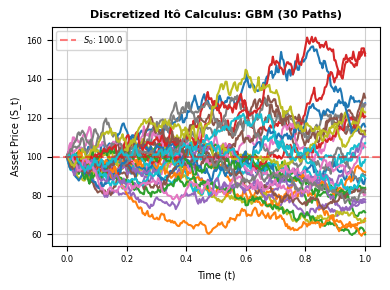

In [4]:
np.random.seed(random_seed)
s0 = 100.0     # Initial asset price
mu = 0.05      # Drift (5% annual return)
sigma = 0.25   # Volatility (25% annual standard deviation)
T = 1.0        # Time horizon (1 year)
N = 252        # Time steps (trading days in a year)
num_paths = 30 # Number of simulated paths

# Run the simulation
X_time_grid = np.linspace(0, T, N + 1)
Y_simulated_paths = simulate_discrete(s0, mu, sigma, T, N, num_paths)

# --- Plotting the Results ---
fig =  plt.figure(figsize=figsize)
ax = fig.add_subplot(111)
ax.plot(X_time_grid, Y_simulated_paths, linewidth=1.5)
ax.set_title(f"Discretized Itô Calculus: GBM ({num_paths} Paths)", fontsize=fontbig, fontweight="bold")
ax.set_xlabel("Time (t)", fontsize=fontmed)
ax.set_ylabel("Asset Price (S_t)", fontsize=fontmed)
ax.grid(True, linestyle="-", alpha=0.6)
ax.axhline(s0, color="red", linestyle="--", alpha=0.5, label=f"$S_0$: {s0}")
ax.tick_params(axis='both', which='major', labelsize=fontsmall) 
ax.legend(loc="upper left", fontsize=fontsmall)
                  
plt.tight_layout()
plt.savefig(imagepath+"/ito_calculus_discrete.pdf", bbox_inches="tight")
if plt_inline_enable:
    plt.show()